In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import keras

import xgboost as xgb
import umap
import shap
import hdbscan

from scipy.stats import uniform, norm, multinomial, bernoulli
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn import tree
from matplotlib import cm, colors

# Data Setup

In [2]:
n = 1500
p = 10

X = uniform.rvs(-5, 10, n*p, random_state=21).reshape(n,p)

beta1 = norm.rvs(0, 1, p, random_state=21)
beta1[0] = 4
beta1[1] = 4

beta2 = norm.rvs(0, 1, p, random_state=12543)
beta2[0] = -4
beta2[1] = -4

beta3 = norm.rvs(0, 1, p, random_state=214)

Y1 = np.array([4*x[0]*x[1] + np.dot(x, beta1) for x in X])
Y2 = np.array([4*x[0]*x[1] + np.dot(x, beta2) for x in X])
Y3 = np.array([-4*x[0]*x[1] + np.dot(x, beta3) for x in X])

pr1 = np.exp(Y1)/(1 + np.exp(Y1) + np.exp(Y2))
pr2 = np.exp(Y2)/(1 + np.exp(Y1) + np.exp(Y2))
pr3 = 1/(1 + np.exp(Y1) + np.exp(Y2))

y = np.array([np.where(multinomial.rvs(1, p=p, random_state=291) == 1,)[0][0] for p in zip(pr1, pr2, pr3)])

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2898)

In [4]:
# pd.DataFrame(X).to_csv("../../DATA/model comparison/simulated/sim_clean.csv", index=False)

# Raw Data

In [5]:
X_umap = umap.UMAP(random_state=2451).fit_transform(X)

/opt/anaconda3/envs/SHAP_ADNI/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


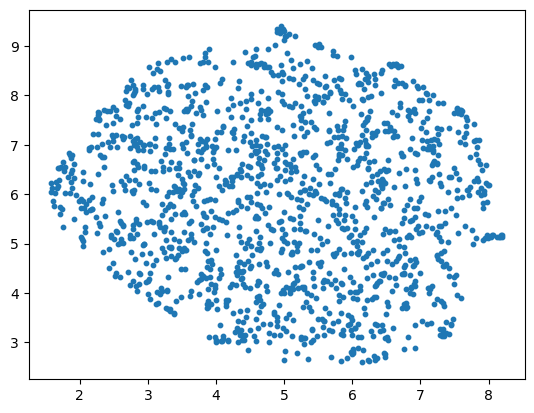

In [6]:
plt.scatter(X_umap[:,0], X_umap[:,1], s=10)

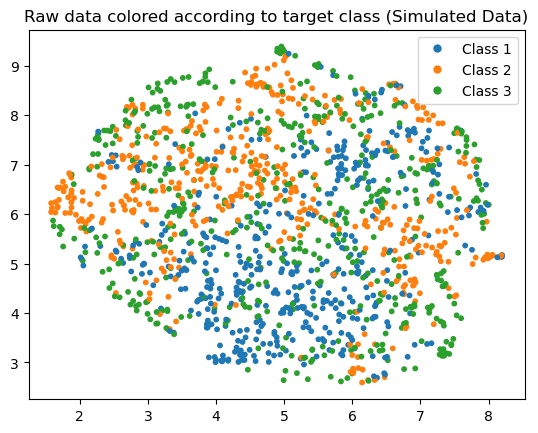

In [7]:
plt.scatter(X_umap[:,0], X_umap[:,1], c=[sns.color_palette()[x] for x in y], s=10)
plt.title("Raw data colored according to target class (Simulated Data)")

labels = ["Class 1", "Class 2", "Class 3"]
lp = lambda i: plt.plot([],color=sns.color_palette()[i], mec="none",
                        label=labels[i], ls="", marker="o")[0]
handles = [lp(i) for i in range(3)]
plt.legend(handles=handles, loc="best")

# Decision Tree

In [8]:
param_grid = {
    'max_depth': range(1, 10, 1),
    'min_samples_leaf': range(1, 20, 2),
    'min_samples_split': range(2, 20, 2),
    'criterion': ["entropy", "gini"]
}

tree_temp = tree.DecisionTreeClassifier(random_state=9503)

grid_search = GridSearchCV(estimator=tree_temp, param_grid=param_grid, 
                           cv=5, verbose=True)
grid_search.fit(X_train, y_train)

print("best accuracy", grid_search.best_score_)
print(grid_search.best_estimator_)

Fitting 5 folds for each of 1620 candidates, totalling 8100 fits
best accuracy 0.8819047619047617
DecisionTreeClassifier(criterion='entropy', max_depth=8, min_samples_leaf=7,
                       random_state=9503)


In [9]:
clf = grid_search.best_estimator_

clf.score(X_test, y_test)

print(classification_report(y_test, clf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90       138
           1       0.86      0.89      0.88       142
           2       0.94      0.86      0.90       170

    accuracy                           0.89       450
   macro avg       0.89      0.89      0.89       450
weighted avg       0.89      0.89      0.89       450



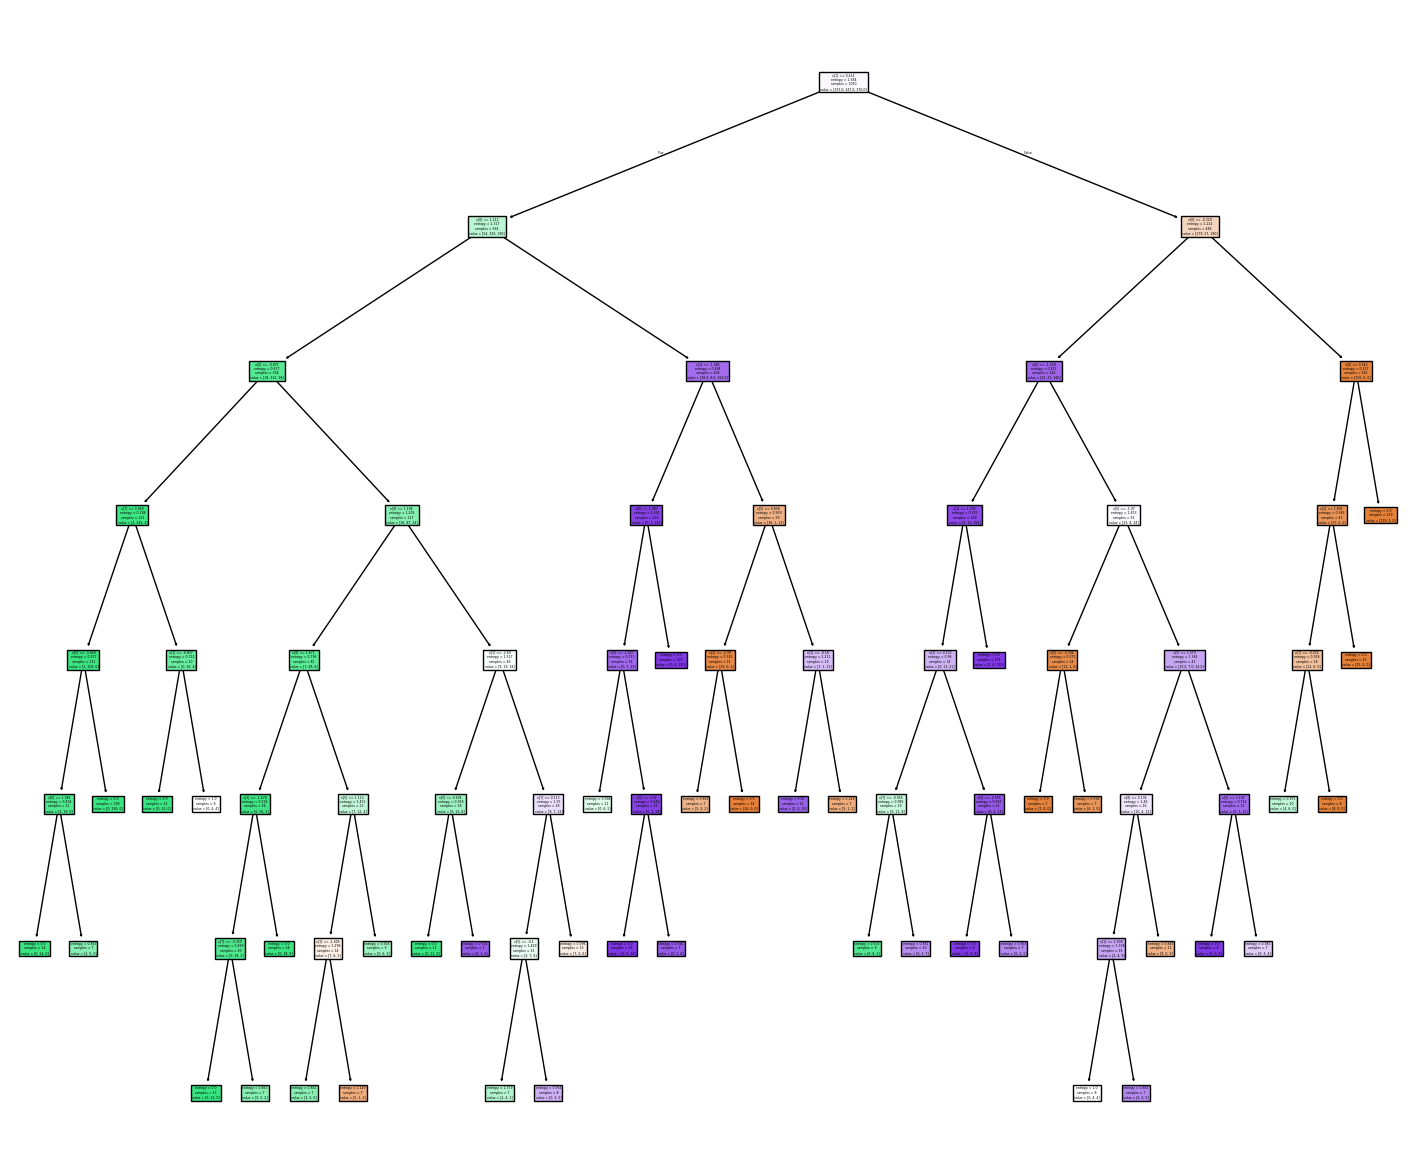

In [10]:
plt.figure(figsize=(18, 15))
tree.plot_tree(clf, filled=True)
plt.show()

## SHAP

In [11]:
explainer_dt = shap.TreeExplainer(clf)
explanation_dt = explainer_dt(X)

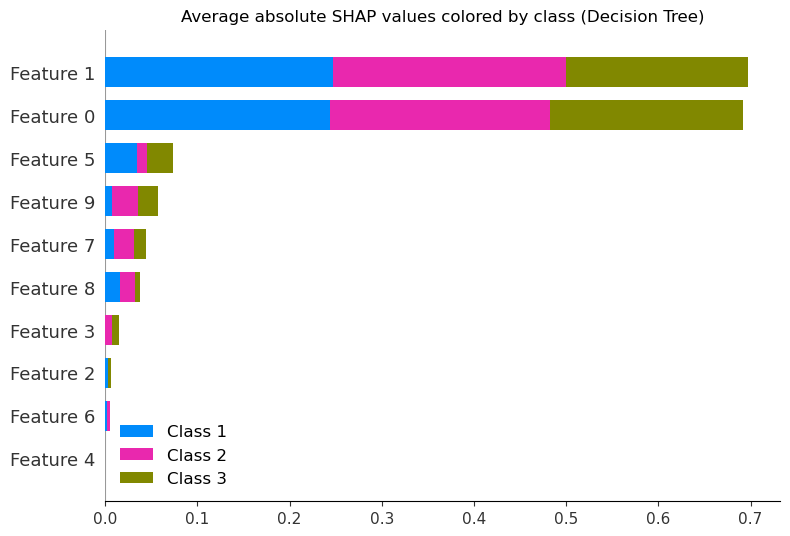

In [12]:
shap.summary_plot(explanation_dt, class_names=['Class 1','Class 2','Class 3'], max_display=10, show=False, class_inds='original')
f = plt.gcf()
ax = plt.gca()

ax.set_title("Average absolute SHAP values colored by class (Decision Tree)")
ax.set_xlabel("")
plt.show()

In [13]:
SHAP_flat_dt = pd.DataFrame(np.asarray([explanation_dt.values[i].flatten() for i in range(explanation_dt.values.shape[0])]),
                            columns=[str(i) + '_' + str(j) for i in range(10) for j in range(3)])

# SHAP_flat_dt.to_csv("../../DATA/model comparison/simulated/sim_shap_dt.csv", index=False)

/opt/anaconda3/envs/SHAP_ADNI/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


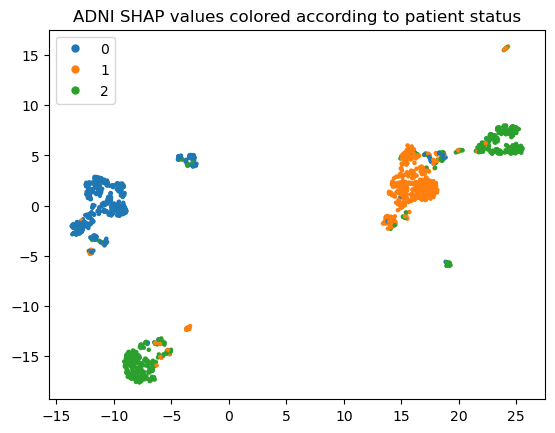

In [14]:
X_umap_SHAP_dt = umap.UMAP(n_neighbors=100, min_dist=0.5, random_state=245).fit_transform(SHAP_flat_dt)

plt.scatter(X_umap_SHAP_dt[:,0], X_umap_SHAP_dt[:,1], c=[sns.color_palette()[int(x)] for x in y], s=5)
plt.title("ADNI SHAP values colored according to patient status")

labels = ["0", "1", "2"]
lp = lambda i: plt.plot([],color=sns.color_palette()[i], mec="none",
                        label=labels[i], ls="", marker="o")[0]
handles = [lp(i) for i in range(3)]
plt.legend(handles=handles, loc="best")

Text(0.5, 1.0, 'SHAP vectors colored according to terminal node (Simulated Data)')

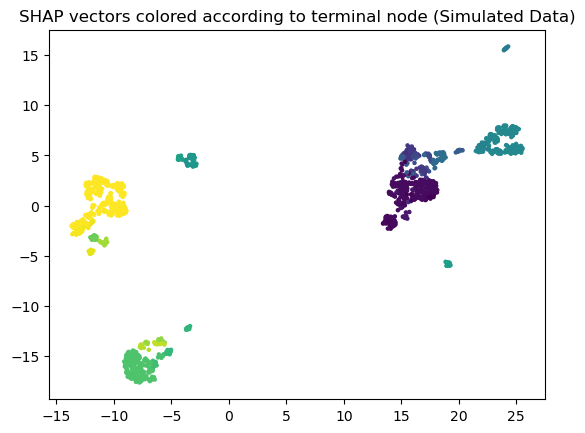

In [15]:
plt.scatter(X_umap_SHAP_dt[:,0], X_umap_SHAP_dt[:,1], c=clf.apply(X), s=5)
plt.title("SHAP vectors colored according to terminal node (Simulated Data)")

# XGBoost

In [16]:
param_grid = {
    'min_child_weight': [1, 5, 10],
    'gamma': [0.5, 1, 1.5, 2, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'max_depth': [3, 4, 5]
}

model_temp = xgb.XGBClassifier(objective='multi:softmax', num_class=3, random_state=29184)

grid_search = GridSearchCV(estimator=model_temp, param_grid=param_grid, 
                           cv=5, verbose=True)
grid_search.fit(X_train, y_train)

print("best accuracy", grid_search.best_score_)
print(grid_search.best_estimator_)

Fitting 5 folds for each of 405 candidates, totalling 2025 fits
best accuracy 0.9390476190476189
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.5, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=3, ...)


In [17]:
model_xgb = grid_search.best_estimator_

print(classification_report(y_test, model_xgb.predict(X_test)))

              precision    recall  f1-score   support

           0       0.95      0.96      0.95       138
           1       0.95      0.97      0.96       142
           2       0.96      0.93      0.94       170

    accuracy                           0.95       450
   macro avg       0.95      0.95      0.95       450
weighted avg       0.95      0.95      0.95       450



## SHAP

In [18]:
explainer_xgb = shap.TreeExplainer(model_xgb)
explanation_xgb = explainer_xgb(X)

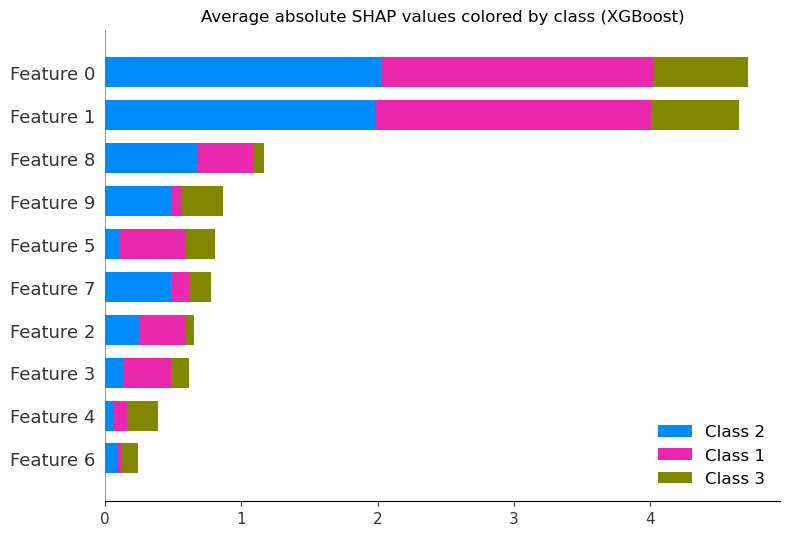

In [19]:
shap.summary_plot(explanation_xgb, class_names=['Class 1','Class 2','Class 3'], max_display=10, show=False)
f = plt.gcf()
ax = plt.gca()

ax.set_title("Average absolute SHAP values colored by class (XGBoost)")
ax.set_xlabel("")
plt.show()

In [20]:
SHAP_flat_xgb = pd.DataFrame(np.asarray([explanation_xgb.values[i].flatten() for i in range(explanation_xgb.values.shape[0])]),
                         columns=[str(i) + '_' + str(j) for i in range(10) for j in range(3)])

# SHAP_flat_xgb.to_csv("../../DATA/model comparison/simulated/sim_shap_xgb.csv", index=False)

/opt/anaconda3/envs/SHAP_ADNI/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


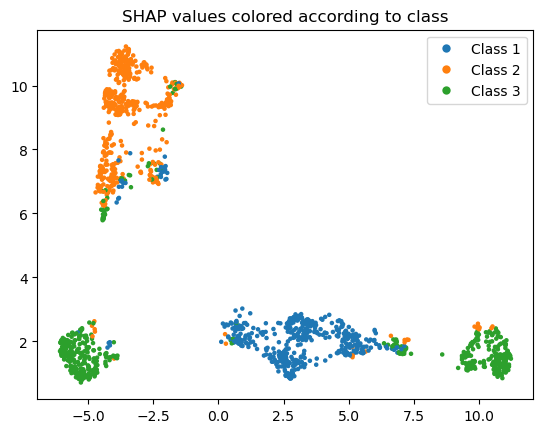

In [21]:
X_umap_SHAP_xgb = umap.UMAP(n_neighbors=80, random_state=251).fit_transform(SHAP_flat_xgb)

plt.scatter(X_umap_SHAP_xgb[:,0], X_umap_SHAP_xgb[:,1], c=[sns.color_palette()[int(x)] for x in y], s=5)
plt.title("SHAP values colored according to class")

labels = ["Class 1", "Class 2", "Class 3"]
lp = lambda i: plt.plot([],color=sns.color_palette()[i], mec="none",
                        label=labels[i], ls="", marker="o")[0]
handles = [lp(i) for i in range(3)]
plt.legend(handles=handles, loc="best")

# Neural Network

In [23]:
keras.utils.set_random_seed(2010)

model_nn = keras.Sequential()
model_nn.add(keras.Input(shape = (X_train.shape[1],)))
model_nn.add(keras.layers.Dense(40, activation = 'relu'))
model_nn.add(keras.layers.Dense(3, activation='softmax'))

model_nn.compile(loss="sparse_categorical_crossentropy", optimizer='adam', metrics=['accuracy'])

model_nn.fit(X_train, y_train, epochs = 100, shuffle = True)

scores = model_nn.evaluate(X_test, y_test)
print(model_nn.metrics_names[0], model_nn.metrics_names[1])

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3495 - loss: 1.6865
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4600 - loss: 1.0852
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6143 - loss: 0.8102
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7343 - loss: 0.6615
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7952 - loss: 0.5706
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8371 - loss: 0.5034
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8590 - loss: 0.4504
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8848 - loss: 0.4062
Epoch 9/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9029 - loss: 0.3698
Epoch 10/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9133 - loss: 0.3374
Epoch 11/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9210 - loss: 0.3095
Epoch 12/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy:

In [24]:
print(classification_report(y_test, np.argmax(model_nn.predict(X_test), axis = -1)))

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       138
           1       0.96      0.96      0.96       142
           2       0.96      0.96      0.96       170

    accuracy                           0.96       450
   macro avg       0.96      0.96      0.96       450
weighted avg       0.96      0.96      0.96       450



## SHAP

In [25]:
# explainer_nn = shap.KernelExplainer(model_nn.predict, shap.kmeans(X, k=30))
# explanation_nn = explainer_nn(X)

# np.savetxt("sim_shap_vals_flat.csv", explanation_nn.values.reshape(1500, -1), delimiter=',')
# np.savetxt("sim_base_vals_flat.csv", explanation_nn.base_values.reshape(1500, -1), delimiter=',')

In [26]:
vals = np.array(pd.read_csv("sim_shap_vals_flat.csv", header=None)).reshape(1500, 10, 3)
base_vals = np.array(pd.read_csv("sim_base_vals_flat.csv", header=None))

explanation_nn = shap.Explanation(values=vals,
                                  base_values=base_vals,
                                  data=X)

/var/folders/7_/f25wqpvj6qz4hhj2lydnm6cr0000gn/T/ipykernel_7342/3618040374.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(explanation_nn, class_names=['Class 1','Class 2','Class 3'], max_display=10, show=False)


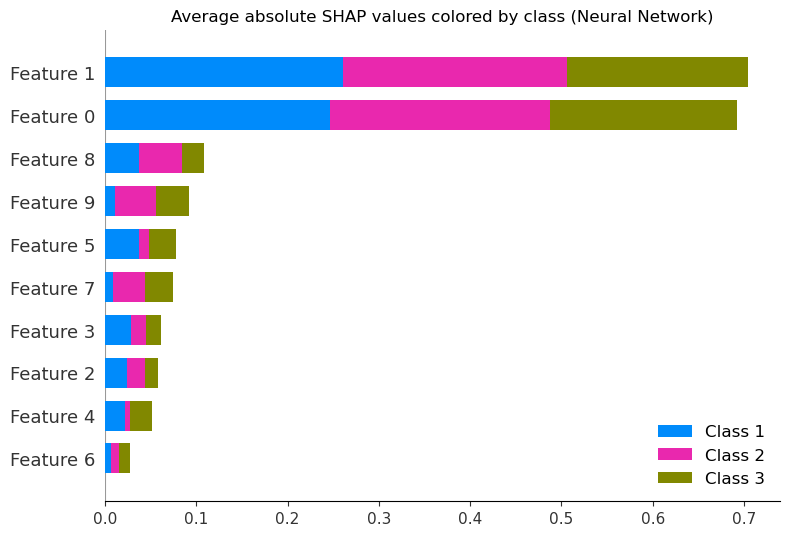

In [27]:
shap.summary_plot(explanation_nn, class_names=['Class 1','Class 2','Class 3'], max_display=10, show=False)
f = plt.gcf()
ax = plt.gca()

ax.set_title("Average absolute SHAP values colored by class (Neural Network)")
ax.set_xlabel("")
plt.show()

In [28]:
SHAP_flat_nn = pd.DataFrame(np.asarray([explanation_nn.values[i].flatten() for i in range(explanation_nn.values.shape[0])]),
                            columns=[str(i) + '_' + str(j) for i in range(10) for j in range(3)])

# SHAP_flat_nn.to_csv("../../DATA/model comparison/simulated/sim_shap_nn.csv", index=False)

/opt/anaconda3/envs/SHAP_ADNI/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0.5, 1.0, 'ADNI SHAP values colored according to patient status')

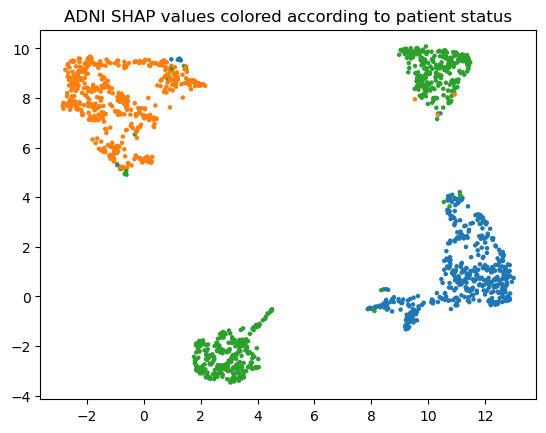

In [29]:
X_umap_SHAP_nn = umap.UMAP(random_state=980).fit_transform(SHAP_flat_nn)

plt.scatter(X_umap_SHAP_nn[:,0], X_umap_SHAP_nn[:,1], c=[sns.color_palette()[int(x)] for x in y], s=5)
plt.title("ADNI SHAP values colored according to patient status")

/opt/anaconda3/envs/SHAP_ADNI/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/SHAP_ADNI/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


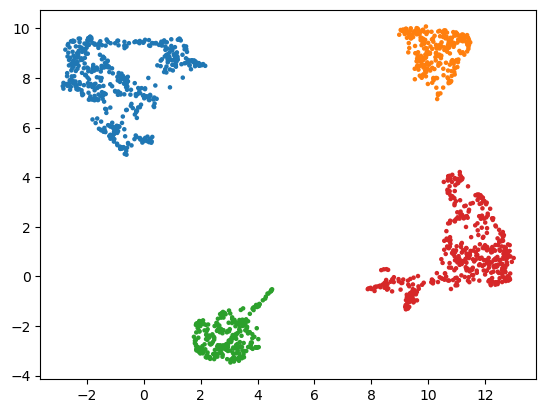

In [30]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=50)
clusterer.fit(X_umap_SHAP_nn)

plt.scatter(X_umap_SHAP_nn[:,0], X_umap_SHAP_nn[:,1], c=[sns.color_palette()[int(x)] for x in clusterer.labels_], s=5)

In [30]:
# np.savetxt("../../DATA/model comparison/simulated/sim_hdbscan.csv", clusterer.labels_, delimiter=",", header="cluster")

# Combined

Text(0.5, 1.0, 'Neural Network')

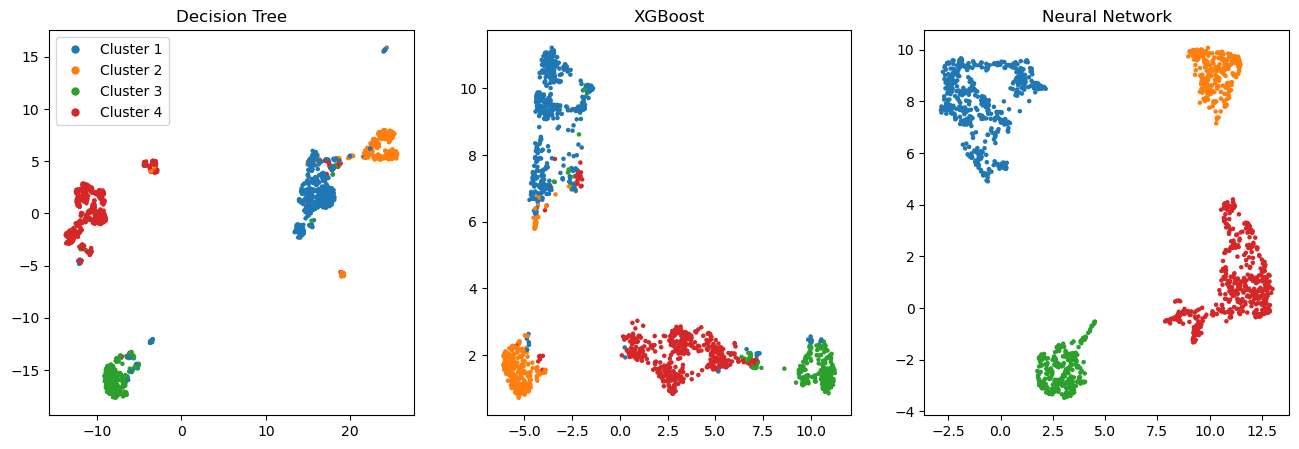

In [31]:
f, (ax1, ax2, ax3) = plt.subplots(1,3)

f.set_size_inches(16, 5)

ax1.scatter(X_umap_SHAP_dt[:,0], X_umap_SHAP_dt[:,1], c=[sns.color_palette()[int(x)] for x in clusterer.labels_], s=5)

labels = ["Cluster 1", "Cluster 2", "Cluster 3", "Cluster 4"]
lp = lambda i: ax1.plot([],color=sns.color_palette()[i], mec="none",
                        label=labels[i], ls="", marker="o")[0]
handles = [lp(i) for i in range(4)]
ax1.legend(handles=handles, loc="best")
ax1.set_title("Decision Tree")

ax2.scatter(X_umap_SHAP_xgb[:,0], X_umap_SHAP_xgb[:,1], c=[sns.color_palette()[int(x)] for x in clusterer.labels_], s=5)
ax2.set_title("XGBoost")

ax3.scatter(X_umap_SHAP_nn[:,0], X_umap_SHAP_nn[:,1], c=[sns.color_palette()[int(x)] for x in clusterer.labels_], s=5)
ax3.set_title("Neural Network")

Text(0.5, 1.0, 'Neural Network')

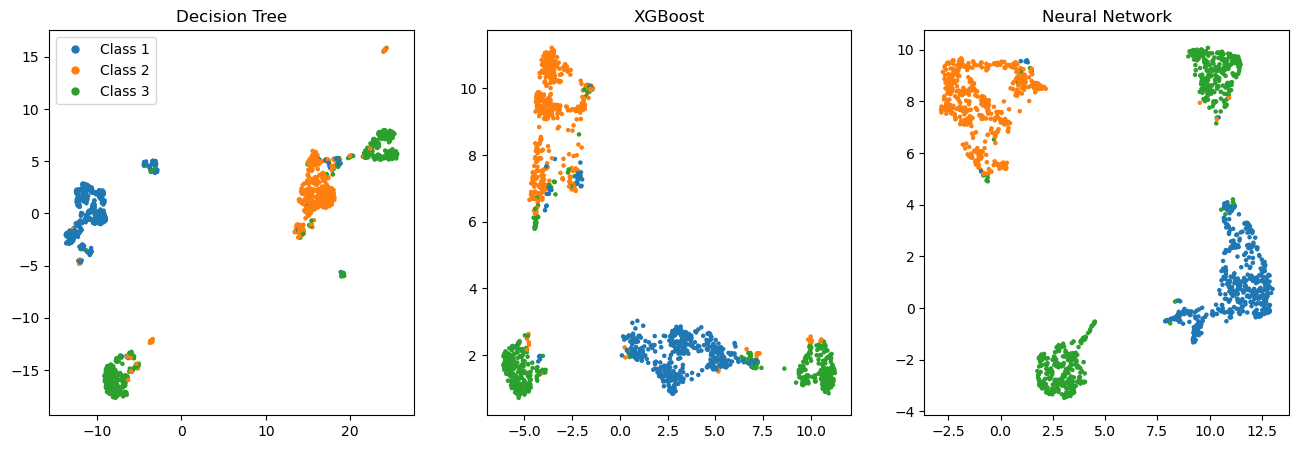

In [32]:
f, (ax1, ax2, ax3) = plt.subplots(1,3)

f.set_size_inches(16, 5)

ax1.scatter(X_umap_SHAP_dt[:,0], X_umap_SHAP_dt[:,1], c=[sns.color_palette()[int(x)] for x in y], s=5)
ax1.set_title("Decision Tree")

labels = ["Class 1", "Class 2", "Class 3"]
lp = lambda i: ax1.plot([],color=sns.color_palette()[i], mec="none",
                        label=labels[i], ls="", marker="o")[0]
handles = [lp(i) for i in range(3)]
ax1.legend(handles=handles, loc="best")

ax2.scatter(X_umap_SHAP_xgb[:,0], X_umap_SHAP_xgb[:,1], c=[sns.color_palette()[int(x)] for x in y], s=5)
ax2.set_title("XGBoost")

ax3.scatter(X_umap_SHAP_nn[:,0], X_umap_SHAP_nn[:,1], c=[sns.color_palette()[int(x)] for x in y], s=5)
ax3.set_title("Neural Network")

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


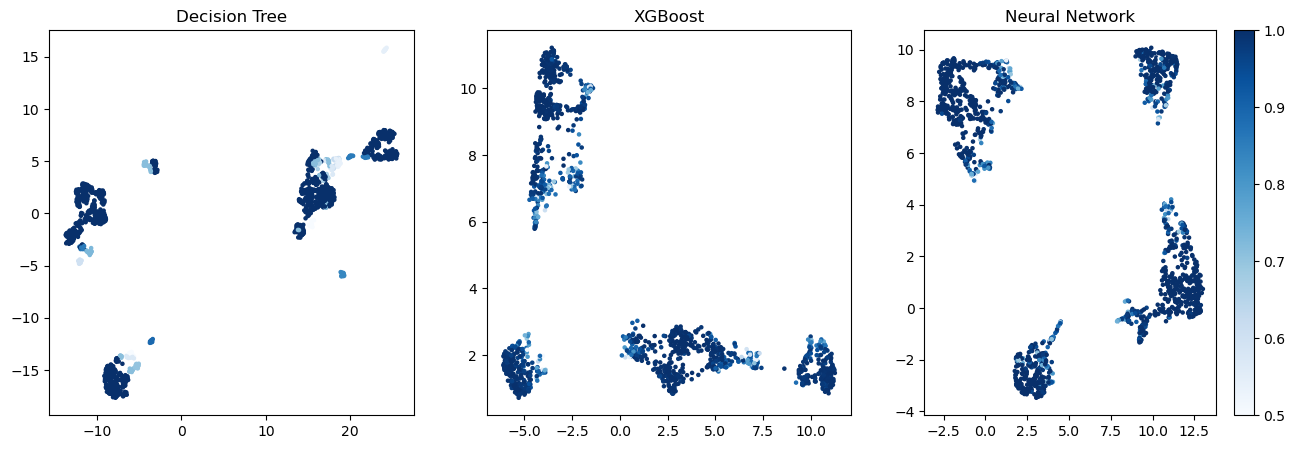

In [34]:
f, (ax1, ax2, ax3) = plt.subplots(1,3)

f.set_size_inches(16, 5)

ax1.scatter(X_umap_SHAP_dt[:,0], X_umap_SHAP_dt[:,1], c=np.amax(clf.predict_proba(X), axis=1), vmin=0.5, vmax=1, cmap="Blues", s=5)
ax1.set_title("Decision Tree")

ax2.scatter(X_umap_SHAP_xgb[:,0], X_umap_SHAP_xgb[:,1], c=np.amax(model_xgb.predict_proba(X), axis=1), vmin=0.5, vmax=1, cmap="Blues", s=5)
ax2.set_title("XGBoost")

ax3.scatter(X_umap_SHAP_nn[:,0], X_umap_SHAP_nn[:,1], c=np.amax(model_nn.predict(X), axis=1), vmin=0.5, vmax=1, cmap="Blues", s=5)
ax3.set_title("Neural Network")

f.colorbar(cm.ScalarMappable(norm=colors.Normalize(0.5, 1), cmap="Blues"), ax=ax3)

In [33]:
raw_heat_df = pd.concat([pd.Series(clusterer.labels_, name="Cluster"), pd.DataFrame(X)], axis=1).groupby('Cluster').mean()[[0, 1, 8, 9]]

Text(0.5, 1.0, 'Heatmap of top features across clusters (Simulated Data)')

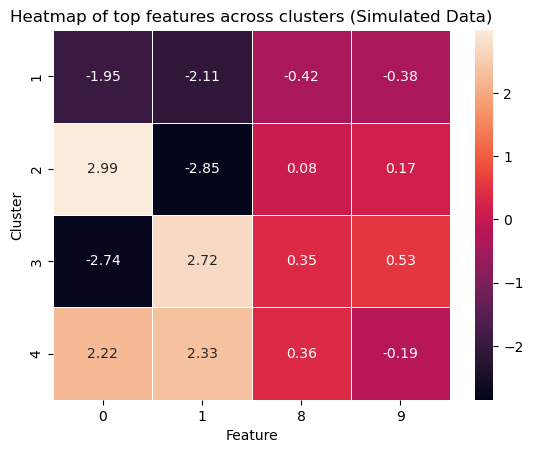

In [34]:
f, ax = plt.subplots()

sns.heatmap(raw_heat_df, yticklabels=['1', '2', '3', '4'], annot=True, linewidth=0.5, fmt=".2f", ax=ax)
ax.set(xlabel = "Feature", ylabel="Cluster")
ax.set_title("Heatmap of top features across clusters (Simulated Data)")